# Week 2 – Classification 
## Overfitting, Regularization, and Regularized Regression

In this notebook we will:

1. Understand **underfitting** and **overfitting**.
2. Introduce **regularization** as a way to control model complexity.
3. Define the **cost function with regularization** and its **derivatives**.
4. Implement **regularized linear regression**.
5. Implement **regularized logistic regression**.

Notation (consistent with Hour 1):

- Vectors (conceptual): $\vec{w}, \vec{x}$.
- Linear regression hypothesis:  
  $$
  f_{\vec{w}, b}(\vec{x}) = \vec{w} \cdot \vec{x} + b.
  $$
- Logistic regression hypothesis:  
  $$
  f_{\vec{w}, b}(\vec{x}) = \sigma(\vec{w} \cdot \vec{x} + b).
  $$
- For sample $i$:  
  $$
  f_{\vec{w}, b}^{(i)}(\vec{x}^{(i)}) = f_{\vec{w}, b}(\vec{x}^{(i)}).
  $$


In [35]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["axes.grid"] = True

## 1. Underfitting and Overfitting

Consider a simple **regression** problem: predict $y$ from $x$.  
Suppose the true relationship is **nonlinear** (for example, a sine wave).

We can choose different models:

- **Underfitting**: model is too simple (e.g., a straight line).
- **Good fit**: model captures the main pattern without memorizing noise.
- **Overfitting**: model is too complex and memorizes noise/outliers.

We will illustrate this using **polynomial regression**:

- Degree 1: underfitting.
- Degree 3: reasonable fit.
- Degree 15: overfitting.


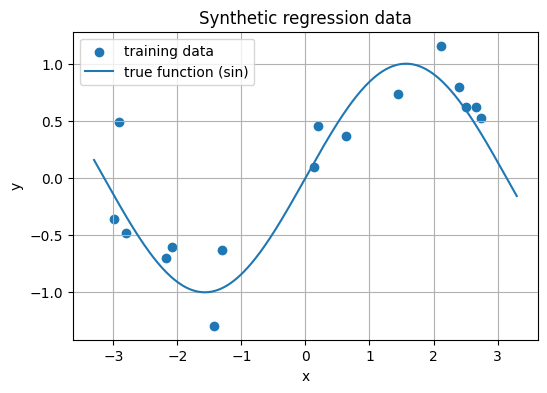

In [36]:
# Generate synthetic 1D regression data
# The small number of noisy points makes overfitting visible.
np.random.seed(12)
m = 16
X_scalar = np.sort(np.random.uniform(-3, 3, m))
y_true = np.sin(X_scalar)
noise = 0.25 * np.random.randn(m)
y = y_true + noise

x_plot = np.linspace(-3.3, 3.3, 400)
y_true_plot = np.sin(x_plot)

plt.figure()
plt.scatter(X_scalar, y, label="training data")
plt.plot(x_plot, y_true_plot, label="true function (sin)")
plt.title("Synthetic regression data")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()


In [37]:
def make_poly_features(x, degree, scale=3.0):
    """
    Create polynomial features [x, x^2, ..., x^degree].

    We use x / scale before taking powers so that high-degree features
    stay numerically comparable. With x in approximately [-3, 3],
    x / 3 lies around [-1, 1].
    """
    x_scaled = x / scale
    X_list = []
    for d in range(1, degree + 1):
        X_list.append(x_scaled ** d)
    return np.vstack(X_list).T  # shape (m, degree)


In [38]:
def fit_linear_regression_closed_form(X, y):
    """Fit linear regression using the normal equation (no regularization)."""
    # Add a column of ones for the bias term
    m = X.shape[0]
    X_bias = np.column_stack([X, np.ones(m)])  # last column is for b
    
    # Solve [w; b] = (X^T X)^-1 X^T y
    theta = np.linalg.pinv(X_bias.T @ X_bias) @ (X_bias.T @ y)
    w = theta[:-1]
    b = theta[-1]
    return w, b


def predict_linear(w, b, X):
    return X @ w + b

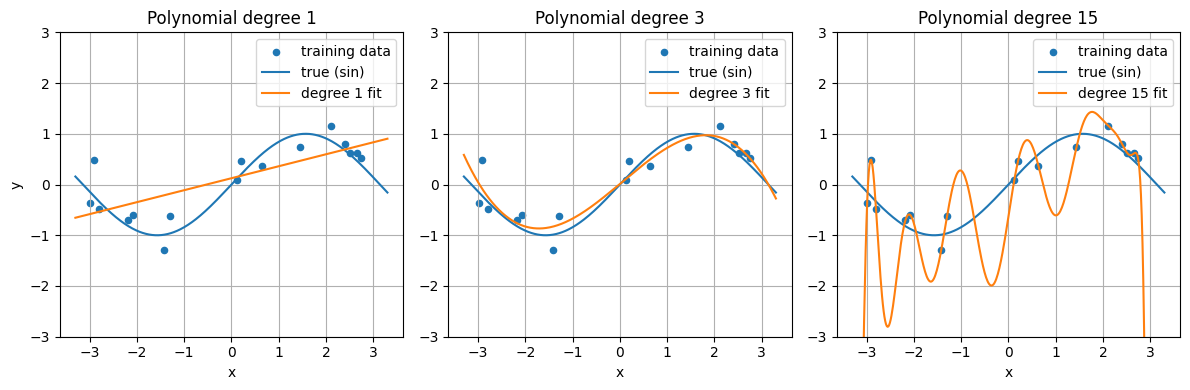

In [39]:
degrees = [1, 3, 15]

plt.figure(figsize=(12, 4))

for i, deg in enumerate(degrees):
    X_poly = make_poly_features(X_scalar, deg)
    w, b = fit_linear_regression_closed_form(X_poly, y)

    X_plot_poly = make_poly_features(x_plot, deg)
    y_plot = predict_linear(w, b, X_plot_poly)

    plt.subplot(1, 3, i + 1)
    plt.scatter(X_scalar, y, label="training data", s=20)
    plt.plot(x_plot, y_true_plot, label="true (sin)")
    plt.plot(x_plot, y_plot, label=f"degree {deg} fit")
    plt.title(f"Polynomial degree {deg}")
    plt.xlabel("x")
    plt.ylim(-3, 3)
    if i == 0:
        plt.ylabel("y")
    plt.legend()

plt.tight_layout()
plt.show()


In the plots:

- **Degree 1** (left): the model is too simple → it **underfits** the data.  
- **Degree 3** (middle): the model follows the main trend → better **generalization**.  
- **Degree 15** (right): the model has enough flexibility to follow noise and become unstable between or outside the observed points → it **overfits**.

The vertical axis is limited so the data remain visible. When the high-degree curve leaves the frame, that is part of the overfitting behavior: the model is reacting too strongly to the particular training sample.

**Goal:** Control model complexity to avoid overfitting.  
One key tool: **regularization**.


## 2. Regularization

In models like polynomial regression, higher-order terms (e.g., $  x^3  $, $  x^5  $, or interaction terms like $  x_1^2 x_2  $) tend to make the model much more flexible and prone to overfitting. They can oscillate wildly to fit noise in the training data.

Idea: penalize **large parameters** so the model prefers **simpler** solutions.

### How Regularization Handles This

Instead of manually deciding which terms are "too complex," regularization adds a general penalty for large coefficients. With polynomial features, especially high-degree terms, overfitting often appears through large coefficients and unstable curves. Penalizing large coefficients discourages this behavior unless the extra flexibility is truly useful.

### L2 regularization

A common type of regularization is called L2 regularization and is defined as follows:

For a parameter vector $\vec{w} = (w_1, \dots, w_n)$, we define the **L2 regularization term**:

$$
R(\vec{w}) = \sum_{j=1}^n w_j^2.
$$

We **do not** include the bias $b$ in this penalty (only the weights).

Regularization adds this penalty to the original cost function, controlled by a
hyperparameter $\lambda \ge 0$:

- $\lambda = 0$: no regularization (risk of overfitting).
- Large $\lambda$: strong penalty (risk of underfitting).
- Intermediate $\lambda$: good compromise.


## 3. Cost Function with Regularization

### 3.1 Regularized Linear Regression

For linear regression we had (without regularization):

$$
J(\vec{w}, b) =
\frac{1}{2m}\sum_{i=1}^m
\left(
f_{\vec{w}, b}^{(i)}(\vec{x}^{(i)}) - y^{(i)}
\right)^2,
$$

with
$$
f_{\vec{w}, b}^{(i)}(\vec{x}^{(i)}) = \vec{w}\cdot\vec{x}^{(i)} + b.
$$

We now add the **L2 regularization term**:

$$
J_{\text{reg}}(\vec{w}, b) =
\frac{1}{2m}\sum_{i=1}^m
\left(
f_{\vec{w}, b}^{(i)}(\vec{x}^{(i)}) - y^{(i)}
\right)^2
+
\frac{\lambda}{2m}\sum_{j=1}^n w_j^2.
$$

Note: the sum over $j$ runs only over the components of $\vec{w}$, not $b$.

### 3.2 Regularized Logistic Regression

For logistic regression, the **unregularized** cost was:

$$
J(\vec{w}, b) =
-\frac{1}{m}
\sum_{i=1}^m
\left[
y^{(i)} \log f_{\vec{w}, b}^{(i)}(\vec{x}^{(i)}) \;+\;
(1 - y^{(i)}) \log\big(1 - f_{\vec{w}, b}^{(i)}(\vec{x}^{(i)})\big)
\right],
$$

with
$$
f_{\vec{w}, b}^{(i)}(\vec{x}^{(i)}) = \sigma(\vec{w}\cdot\vec{x}^{(i)} + b).
$$

The **regularized** cost is:

$$
J_{\text{reg}}(\vec{w}, b) =
-\frac{1}{m}
\sum_{i=1}^m
\left[
y^{(i)} \log f_{\vec{w}, b}^{(i)}(\vec{x}^{(i)}) \;+\;
(1 - y^{(i)}) \log\big(1 - f_{\vec{w}, b}^{(i)}(\vec{x}^{(i)})\big)
\right]
+
\frac{\lambda}{2m}\sum_{j=1}^n w_j^2.
$$


### 3.3 Gradients for Regularized Linear Regression

Recall:
$$
J_{\text{reg}}(\vec{w}, b) =
\frac{1}{2m}\sum_{i=1}^m
\left(
f_{\vec{w}, b}^{(i)}(\vec{x}^{(i)}) - y^{(i)}
\right)^2
+
\frac{\lambda}{2m}\sum_{j=1}^n w_j^2,
$$
with
$$
f_{\vec{w}, b}^{(i)}(\vec{x}^{(i)}) = \vec{w}\cdot\vec{x}^{(i)} + b.
$$

Define the error for each example:
$$
e^{(i)} = f_{\vec{w}, b}^{(i)}(\vec{x}^{(i)}) - y^{(i)}.
$$

Then, for each weight $w_j$:
$$
\frac{\partial J_{\text{reg}}}{\partial w_j}
=
\frac{1}{m}\sum_{i=1}^m e^{(i)} x^{(i)}_j
+
\frac{\lambda}{m} w_j,
$$

and for the bias:
$$
\frac{\partial J_{\text{reg}}}{\partial b}
=
\frac{1}{m}\sum_{i=1}^m e^{(i)}.
$$

These are the derivatives used in **gradient descent**:
$$
w_j := w_j - \alpha \frac{\partial J_{\text{reg}}}{\partial w_j},
\quad
b := b - \alpha \frac{\partial J_{\text{reg}}}{\partial b}.
$$


In [41]:
def compute_cost_lin_reg_reg(w, b, X, y, lam):
    """Regularized linear regression cost J_reg(w, b)."""
    m, n = X.shape
    preds = X @ w + b  # f_{w,b}^{(i)}(x^{(i)})
    errors = preds - y
    mse_term = (1 / (2 * m)) * np.sum(errors ** 2)
    reg_term = (lam / (2 * m)) * np.sum(w ** 2)
    return mse_term + reg_term


def compute_gradient_lin_reg_reg(w, b, X, y, lam):
    """Gradient of regularized linear regression cost w.r.t w and b."""
    m, n = X.shape
    preds = X @ w + b
    errors = preds - y
    
    dj_dw = (1 / m) * (X.T @ errors) + (lam / m) * w
    dj_db = (1 / m) * np.sum(errors)
    return dj_dw, dj_db


def gradient_descent_lin_reg_reg(X, y, w_init, b_init, alpha, lam, num_iters):
    w = w_init.copy()
    b = b_init
    J_history = []
    for i in range(num_iters):
        dj_dw, dj_db = compute_gradient_lin_reg_reg(w, b, X, y, lam)
        w -= alpha * dj_dw
        b -= alpha * dj_db
        J_history.append(compute_cost_lin_reg_reg(w, b, X, y, lam))
    return w, b, J_history

For **regularized linear regression**, there is a **closed-form analytical solution**, known as **ridge regression**. 

Compared to gradient descent, the ridge closed-form solution has several advantages:

- Is **exact** (for this cost function): we obtain the global minimizer directly.
- Has **no learning rate** to tune.
- Is **numerically stable** for polynomial features of moderate degree.
- Produces **predictable, clean plots**:
  - $\lambda = 0$: strong overfitting (wiggly curve),
  - Intermediate $\lambda$: controlled complexity,
  - Large $\lambda$: underfitting (almost linear).

For our polynomial regression demo, this is ideal:  
students can clearly see the effect of **the same degree, different $\lambda$** on the shape of the curve.

The ridge closed-form method also has limitations:

- It requires computing the inverse (or pseudo-inverse) of a $(n+1) \times (n+1)$ matrix.
  - This is fine for small or moderate $n$,
  - But can be expensive when $n$ is very large.
- It only exists for **linear models** with quadratic costs.
  - There is no closed-form solution for logistic regression,
  - Nor for neural networks and most deep learning models.

So, while perfect for our **regularized linear regression demo**, it is **not a general replacement** for gradient descent.

The code above shows the implementation of gradient descent with regularization. However, for the demo we use the ridge regression method defined below. You can find a detailed explanation in the appendix [here.](./APENDIX-RidgeVsGradientDescentInRegularizedLinearRegression.ipynb)


In [42]:
def fit_linear_regression_ridge(X, y, lam):
    """
    Closed-form ridge regression:
    minimize (1/(2m)) ||Xw + b - y||^2 + (lam/(2m)) ||w||^2
    We do NOT regularize the bias term.
    """
    m, n = X.shape
    # Add bias column
    X_bias = np.column_stack([X, np.ones(m)])  # shape (m, n+1)

    # Identity for regularization (do not regularize bias -> last entry = 0)
    I = np.eye(n + 1)
    I[-1, -1] = 0.0

    # Ridge solution: theta = (X^T X + lam * I)^(-1) X^T y
    theta = np.linalg.pinv(X_bias.T @ X_bias + lam * I) @ (X_bias.T @ y)
    w = theta[:-1]
    b = theta[-1]
    return w, b


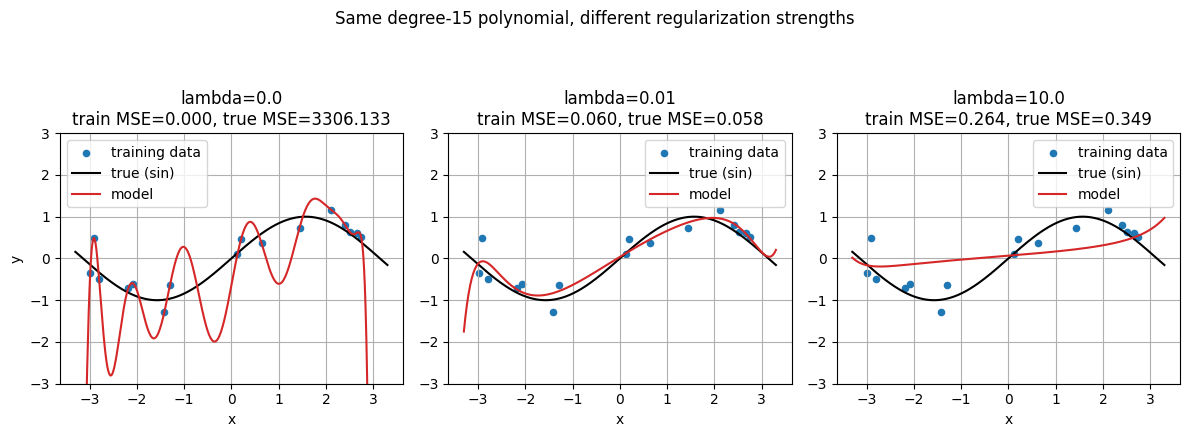

In [43]:
# Compare fits for the same high-degree polynomial with different lambda values.
# The degree stays fixed; only the regularization strength changes.

degree = 15
X_poly_high = make_poly_features(X_scalar, degree)
X_plot_poly_high = make_poly_features(x_plot, degree)

lambdas = [0.0, 0.01, 10.0]

plt.figure(figsize=(12, 4))

for i, lam in enumerate(lambdas):
    w_reg, b_reg = fit_linear_regression_ridge(X_poly_high, y, lam)
    y_train_reg = predict_linear(w_reg, b_reg, X_poly_high)
    y_plot_reg = predict_linear(w_reg, b_reg, X_plot_poly_high)

    train_mse = np.mean((y_train_reg - y) ** 2)
    true_mse = np.mean((y_plot_reg - y_true_plot) ** 2)

    plt.subplot(1, 3, i + 1)
    plt.scatter(X_scalar, y, label="training data", s=20)
    plt.plot(x_plot, y_true_plot, "k-", label="true (sin)")
    plt.plot(x_plot, y_plot_reg, color="tab:red", label="model")
    plt.title(f"lambda={lam}\ntrain MSE={train_mse:.3f}, true MSE={true_mse:.3f}")
    plt.xlabel("x")
    plt.ylim(-3, 3)
    if i == 0:
        plt.ylabel("y")
    plt.legend()

plt.suptitle("Same degree-15 polynomial, different regularization strengths", y=1.08)
plt.tight_layout()
plt.show()


In the plots above, the polynomial degree is always **15**. Only $\lambda$ changes.

- **$\lambda = 0$**: no regularization. The model can make the training error almost zero, but the curve becomes unstable and overfits the sample.
- **Small $\lambda$**: the model is still flexible, but the weights are constrained. The curve follows the main pattern instead of every fluctuation.
- **Large $\lambda$**: the weights are strongly shrunk toward zero. The curve becomes too simple and starts to underfit.

Regularization does not change the degree of the polynomial. It changes how large the learned parameters are allowed to become.


## 4. Regularized Logistic Regression

We now implement **regularized logistic regression**.

Recall the (unregularized) hypothesis:
$$
f_{\vec{w}, b}^{(i)}(\vec{x}^{(i)}) = \sigma(\vec{w} \cdot \vec{x}^{(i)} + b).
$$

Regularized cost:
$$
J_{\text{reg}}(\vec{w}, b) =
-\frac{1}{m}
\sum_{i=1}^m
\left[
y^{(i)} \log f_{\vec{w}, b}^{(i)}(\vec{x}^{(i)}) \;+\;
(1 - y^{(i)}) \log\big(1 - f_{\vec{w}, b}^{(i)}(\vec{x}^{(i)})\big)
\right]
+
\frac{\lambda}{2m}\sum_{j=1}^n w_j^2.
$$


### 4.1 Gradients for Regularized Logistic Regression

For each example:
$$
f_{\vec{w}, b}^{(i)}(\vec{x}^{(i)}) = \sigma(\vec{w}\cdot\vec{x}^{(i)} + b).
$$

Define the error:
$$
e^{(i)} = f_{\vec{w}, b}^{(i)}(\vec{x}^{(i)}) - y^{(i)}.
$$

Then the gradients of the regularized cost are:

For each weight $w_j$:
$$
\frac{\partial J_{\text{reg}}}{\partial w_j}
=
\frac{1}{m}\sum_{i=1}^m e^{(i)} x^{(i)}_j
+
\frac{\lambda}{m} w_j,
$$

and for the bias:
$$
\frac{\partial J_{\text{reg}}}{\partial b}
=
\frac{1}{m}\sum_{i=1}^m e^{(i)}.
$$

Gradient descent updates are:

$$
w_j := w_j - \alpha \frac{\partial J_{\text{reg}}}{\partial w_j},
\quad
b := b - \alpha \frac{\partial J_{\text{reg}}}{\partial b}.
$$


In [44]:
def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))


def compute_cost_log_reg_reg(w, b, X, y, lam):
    """Regularized logistic regression cost."""
    m, n = X.shape
    z = X @ w + b
    f = sigmoid(z)  # f_{w,b}^{(i)}(x^{(i)})
    eps = 1e-8
    f_clipped = np.clip(f, eps, 1 - eps)
    # Cross-entropy term
    ce = - (1 / m) * np.sum(
        y * np.log(f_clipped) + (1 - y) * np.log(1 - f_clipped)
    )
    # Regularization term
    reg = (lam / (2 * m)) * np.sum(w ** 2)
    return ce + reg


def compute_gradient_log_reg_reg(w, b, X, y, lam):
    """Gradient of regularized logistic regression cost."""
    m, n = X.shape
    z = X @ w + b
    f = sigmoid(z)
    error = f - y  # f_{w,b}^{(i)}(x^{(i)}) - y^{(i)}
    dj_dw = (1 / m) * (X.T @ error) + (lam / m) * w
    dj_db = (1 / m) * np.sum(error)
    return dj_dw, dj_db


def gradient_descent_log_reg_reg(X, y, w_init, b_init, alpha, lam, num_iters):
    w = w_init.copy()
    b = b_init
    J_history = []
    for i in range(num_iters):
        dj_dw, dj_db = compute_gradient_log_reg_reg(w, b, X, y, lam)
        w -= alpha * dj_dw
        b -= alpha * dj_db
        J_history.append(compute_cost_log_reg_reg(w, b, X, y, lam))
    return w, b, J_history


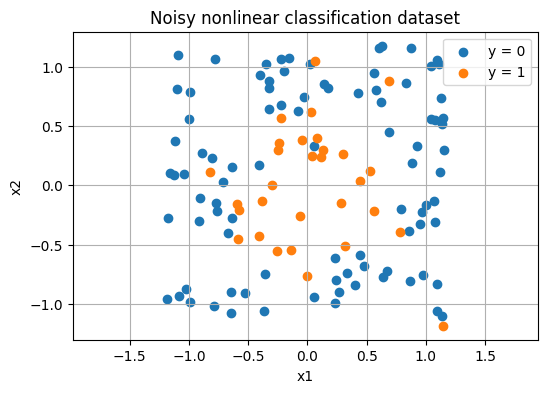

In [45]:
# Create a nonlinear 2D classification dataset.
# Points near the center mostly belong to class 1; points farther away mostly belong to class 0.
np.random.seed(4)
m_class = 120
X_class = np.random.uniform(-1.2, 1.2, size=(m_class, 2))
radius = np.sqrt(X_class[:, 0] ** 2 + X_class[:, 1] ** 2)
y_class = (radius < 0.65).astype(float)

# Flip a few labels to make the dataset noisy.
# Without regularization, a flexible model may try to adapt to these exceptions.
num_flips = 10
flip_idx = np.random.choice(m_class, size=num_flips, replace=False)
y_class[flip_idx] = 1 - y_class[flip_idx]

plt.figure()
plt.scatter(X_class[y_class == 0, 0], X_class[y_class == 0, 1], label="y = 0")
plt.scatter(X_class[y_class == 1, 0], X_class[y_class == 1, 1], label="y = 1")
plt.title("Noisy nonlinear classification dataset")
plt.xlabel("x1")
plt.ylabel("x2")
plt.axis("equal")
plt.legend()
plt.show()


Before plotting the decision boundaries, we will show two numbers in each title:

- **Accuracy**: the fraction of training examples classified correctly. For example, an accuracy of `0.90` means that 90% of the points are classified correctly.
- **$||w||$**: the size, or norm, of the weight vector. A larger $||w||$ means the model is using larger coefficients; a smaller $||w||$ means regularization has shrunk the coefficients.

These two numbers help read the effect of regularization. Accuracy tells us how well the model fits the labeled points. $||w||$ tells us how large or complex the learned parameters are.


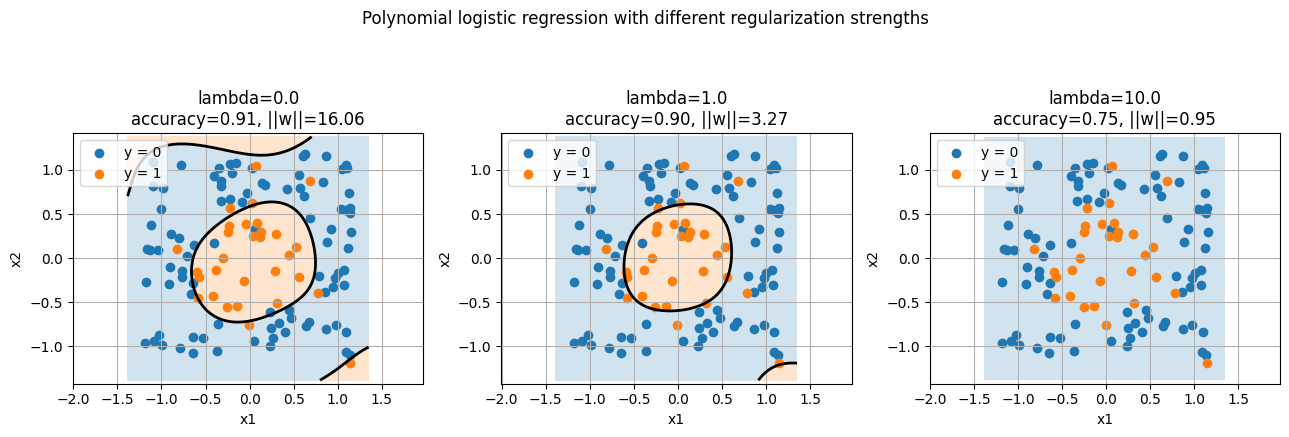

In [46]:
def make_polynomial_features_2d(X, degree):
    """Create polynomial features x1^a x2^b for total degree 1 through degree."""
    x1 = X[:, 0]
    x2 = X[:, 1]
    features = []
    for total_degree in range(1, degree + 1):
        for power_x2 in range(total_degree + 1):
            power_x1 = total_degree - power_x2
            features.append((x1 ** power_x1) * (x2 ** power_x2))
    return np.vstack(features).T


def plot_decision_boundary_logreg(w, b, X_original, y, degree, title):
    x_min, x_max = X_original[:, 0].min() - 0.2, X_original[:, 0].max() + 0.2
    y_min, y_max = X_original[:, 1].min() - 0.2, X_original[:, 1].max() + 0.2
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 250),
                         np.linspace(y_min, y_max, 250))
    grid_original = np.c_[xx.ravel(), yy.ravel()]
    grid_poly = make_polynomial_features_2d(grid_original, degree)
    probs = sigmoid(grid_poly @ w + b).reshape(xx.shape)

    plt.contourf(xx, yy, probs, levels=[0, 0.5, 1], alpha=0.2,
                 colors=["tab:blue", "tab:orange"])
    plt.contour(xx, yy, probs, levels=[0.5], colors="black", linewidths=2)
    plt.scatter(X_original[y == 0, 0], X_original[y == 0, 1], label="y = 0")
    plt.scatter(X_original[y == 1, 0], X_original[y == 1, 1], label="y = 1")
    plt.title(title)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.axis("equal")
    plt.legend()


# Compare weak, moderate, and strong regularization using the same polynomial features.
poly_degree = 6
X_class_poly = make_polynomial_features_2d(X_class, poly_degree)
lambdas = [0.0, 1.0, 10.0]

plt.figure(figsize=(13, 4))

for i, lam in enumerate(lambdas):
    w0 = np.zeros(X_class_poly.shape[1])
    b0 = 0.0
    w_reg, b_reg, J_hist = gradient_descent_log_reg_reg(
        X_class_poly, y_class, w0, b0, alpha=0.8, lam=lam, num_iters=6000
    )
    probabilities = sigmoid(X_class_poly @ w_reg + b_reg)
    predictions = (probabilities >= 0.5).astype(float)
    accuracy = np.mean(predictions == y_class)

    plt.subplot(1, 3, i + 1)
    plot_decision_boundary_logreg(
        w_reg,
        b_reg,
        X_class,
        y_class,
        degree=poly_degree,
        title=f"lambda={lam}\naccuracy={accuracy:.2f}, ||w||={np.linalg.norm(w_reg):.2f}",
    )

plt.suptitle("Polynomial logistic regression with different regularization strengths", y=1.08)
plt.tight_layout()
plt.show()


In the logistic regression plots, the feature set is the same in all three panels: polynomial features up to degree 6. Only $\lambda$ changes.

- **$\lambda = 0$**: the model is free to use large weights, so the boundary can bend more to adapt to noisy points.
- **Moderate $\lambda$**: the weights are smaller, and the boundary becomes smoother.
- **Large $\lambda$**: the weights are strongly constrained. The model becomes too simple and may classify most points as the majority class.

Regularization does not remove polynomial features from the model. It makes it harder for the model to rely on them with very large coefficients.


## Summary (Hour 2)

In this notebook we:

1. Visualized **underfitting** and **overfitting** using polynomial regression.
2. Introduced **L2 regularization** to penalize large weights:
   $$
   R(\vec{w}) = \sum_{j=1}^n w_j^2.
   $$
3. Defined **regularized cost functions** and their **derivatives**:
   - For linear regression:
     $$
     J_{\text{reg}}(\vec{w}, b) =
     \frac{1}{2m}\sum_{i=1}^m
     \left(
     f_{\vec{w}, b}^{(i)}(\vec{x}^{(i)}) - y^{(i)}
     \right)^2
     + \frac{\lambda}{2m}\sum_{j=1}^n w_j^2,
     $$
     $$
     \frac{\partial J_{\text{reg}}}{\partial w_j}
     =
     \frac{1}{m}\sum_{i=1}^m e^{(i)} x^{(i)}_j
     +
     \frac{\lambda}{m} w_j,
     \quad
     \frac{\partial J_{\text{reg}}}{\partial b}
     =
     \frac{1}{m}\sum_{i=1}^m e^{(i)}.
     $$
   - For logistic regression:
     $$
     J_{\text{reg}}(\vec{w}, b) =
     -\frac{1}{m}
     \sum_{i=1}^m
     \left[
     y^{(i)} \log f_{\vec{w}, b}^{(i)}(\vec{x}^{(i)}) \;+\;
     (1 - y^{(i)}) \log\big(1 - f_{\vec{w}, b}^{(i)}(\vec{x}^{(i)})\big)
     \right]
     +
     \frac{\lambda}{2m}\sum_{j=1}^n w_j^2,
     $$
     with analogous gradients:
     $$
     \frac{\partial J_{\text{reg}}}{\partial w_j}
     =
     \frac{1}{m}\sum_{i=1}^m e^{(i)} x^{(i)}_j
     +
     \frac{\lambda}{m} w_j,
     \quad
     \frac{\partial J_{\text{reg}}}{\partial b}
     =
     \frac{1}{m}\sum_{i=1}^m e^{(i)}.
     $$
4. Implemented **regularized linear regression** and saw how $\lambda$ affects the fit of a high-degree polynomial.
5. Implemented **regularized logistic regression** and visualized decision boundaries with and without regularization.

These derivations make explicit how **gradient descent** is applied when we include
regularization in both linear and logistic regression.
